# Optuna HPO v4 — Precision-Focused, Symmetry-Locked

Fourth-pass hyperparameter search: **freeze symmetry HPs** (already optimal from trial #71)
and focus on **fundamental-domain precision**.

**Insight from v2:** Trial #71 (Soft=2.131 µm) improved Soft mainly via Acc (87.5→88.4%), but
Fund *regressed* (0.87→0.93 µm). Pre-Optuna configs achieved Fund=0.87 with Acc=88.3%.
The information is there — we need to let the optimizer explore the precision axis.

**Strategy:**
- **Lock 6 symmetry HPs** at trial #71 values (focal alphas, gamma, λ_focal) — proven optimal
- **Unlock `lambda_fund`** (was fixed at 1.0) — key new lever to explicitly weight Fund regression
- **Wider ranges** for optimizer/schedule HPs — more freedom for precision regimes
- **9 searched HPs** (vs 14 in v3) → TPE explores more efficiently

| Group | Parameters | Range |
|-------|-----------|------|
| Optimizer | `lr_max`, `weight_decay` | [8e-4, 6e-3], [1e-5, 5e-4] log |
| Schedule | `warmup_ep`, `n_cycles`, `eta_min` | [25, 60], [8,10,12,15], [5e-8, 2e-6] |
| Loss weights | `lambda_fund`, `lambda_soft`, `lambda_usign` | **[0.8, 3.0]**, [0.3, 1.5], [0.2, 0.8] |
| Temperature | `t_train` | [0.10, 0.35] |

**Frozen at trial #71:** `focal_gamma=1.873`, `focal_alpha=[0.894, 0.867, 1.345, 1.091]`, `lambda_focal=1.181`
**Fixed at trial #43:** `batch=384`, `mlp_hidden=128`, `dropout_mlp=0.227`, `dropout_fusion=0.038`, `aug_noise=0.023`, `aug_shift=3`, `aug_scale=0.052`

In [1]:
# ============================================================
# §1  Imports, Data Loading, Global Setup
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, os, time, copy, random, gc
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

try:
    import optuna
    from optuna.pruners import PercentilePruner
    from optuna.samplers import TPESampler
except ImportError:
    !pip install -q optuna
    import optuna
    from optuna.pruners import PercentilePruner
    from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Device ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Optuna {optuna.__version__} | Device: {device}')
if device.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

# --- Load data ---
DATA_DIR = Path('.')
if os.path.exists('/kaggle/input/notebooks/ibongarciagomez/nb-feature-engineering'):
    DATA_DIR = Path('/kaggle/input/notebooks/ibongarciagomez/nb-feature-engineering')
elif os.path.exists('model_input.npz'):
    DATA_DIR = Path('.')
else:
    raise FileNotFoundError('model_input.npz not found. Run NB_Feature_Engineering first.')

data = np.load(DATA_DIR / 'model_input.npz')

all_scalars         = data['mlp_input']              # (N, 110)
wf_2ch              = data['cnn_input']              # (N, 2, 90)
targets_fund_scaled = data['targets_fund_scaled']    # (N, 2)
targets_xy          = data['targets_xy']             # (N, 2)
targets_fund        = data['targets_fund']           # (N, 2)
q_all               = data['quadrant']               # (N,)
u_sign_all          = data['u_sign']                 # (N,)
r_all               = data['radius']                 # (N,)
idx_train           = data['idx_train']
idx_test            = data['idx_test']
target_mean         = data['target_mean']
target_scale        = data['target_scale']
geom                = data['geometry']
dims                = data['dims']

X_C, Y_C, PHI0 = float(geom[0]), float(geom[1]), float(geom[2])
N_MLP_IN  = int(dims[5])
N_BINS    = int(dims[6])
N_SECTORS = int(dims[7])
N = len(q_all)
xf_all = targets_fund[:, 0]
yf_all = targets_fund[:, 1]

class _TargetScaler:
    def __init__(self, mean, scale):
        self.mean_ = mean
        self.scale_ = scale
target_scaler = _TargetScaler(target_mean, target_scale)

print(f'\nData loaded: {N:,} events, MLP={N_MLP_IN}-d, CNN=2×{N_BINS}')
print(f'Train: {len(idx_train):,} | Test: {len(idx_test):,}')

PyTorch 2.9.0+cu126 | Optuna 4.7.0 | Device: cuda
   GPU: Tesla P100-PCIE-16GB



Data loaded: 17,473 events, MLP=110-d, CNN=2×90
Train: 13,871 | Test: 3,602


In [2]:
# ============================================================
# §2  Model, Dataset, Loss — Parameterized Versions
# ============================================================

# C2v sign tables (global, reused by all trials)
U_SIGNS = torch.tensor([1.0,  1.0, -1.0, -1.0], device=device)
V_SIGNS = torch.tensor([1.0, -1.0, -1.0,  1.0], device=device)


class MultiDomainDataset(Dataset):
    def __init__(self, indices, wf_2ch, scalars_all, targets_uv,
                 targets_xy_orig, q, u_sign, augment=False,
                 noise_std=0.03, shift_max=2, scale_range=0.03):
        self.wf_2ch  = torch.tensor(wf_2ch[indices], dtype=torch.float32)
        self.scalars = torch.tensor(scalars_all[indices], dtype=torch.float32)
        self.uv      = torch.tensor(targets_uv[indices], dtype=torch.float32)
        self.xy      = torch.tensor(targets_xy_orig[indices], dtype=torch.float32)
        self.q       = torch.tensor(q[indices], dtype=torch.long)
        self.u_sign  = torch.tensor(u_sign[indices], dtype=torch.float32)
        self.augment = augment
        self.noise_std   = noise_std
        self.shift_max   = shift_max
        self.scale_range = scale_range

    def __len__(self):
        return len(self.q)

    def __getitem__(self, i):
        wf = self.wf_2ch[i]
        if self.augment:
            if torch.rand(1) < 0.5:
                wf = wf + torch.randn(1, wf.shape[1]) * self.noise_std
            if torch.rand(1) < 0.5:
                shift = torch.randint(-self.shift_max, self.shift_max + 1, (1,)).item()
                wf = torch.roll(wf, shift, dims=-1)
            if torch.rand(1) < 0.3:
                lo = 1.0 - self.scale_range
                wf = wf * (lo + torch.rand(1).item() * 2 * self.scale_range)
        return wf, self.scalars[i], self.uv[i], self.xy[i], self.q[i], self.u_sign[i]


class ResBlock1D(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(channels), nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(channels))
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.block(x))


class MultiDomainCNN(nn.Module):
    def __init__(self, n_mlp_in=110, n_sectors=4, mlp_hidden=160,
                 dropout_mlp=0.1, dropout_fusion=0.1):
        super().__init__()
        self.cnn_stem = nn.Sequential(
            nn.Conv1d(2, 32, 7, padding=3), nn.BatchNorm1d(32), nn.GELU(), nn.MaxPool1d(2))
        self.cnn_res1 = ResBlock1D(32)
        self.cnn_mid = nn.Sequential(
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.GELU(), nn.MaxPool1d(2))
        self.cnn_res2 = ResBlock1D(64)
        self.cnn_deep = nn.Sequential(
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.GELU(), nn.MaxPool1d(2))
        self.cnn_res3 = ResBlock1D(128)
        self.cnn_head = nn.Sequential(
            nn.Conv1d(128, 128, 3, padding=1), nn.BatchNorm1d(128), nn.GELU(),
            nn.AdaptiveAvgPool1d(1))

        self.mlp = nn.Sequential(
            nn.Linear(n_mlp_in, mlp_hidden), nn.BatchNorm1d(mlp_hidden), nn.GELU(),
            nn.Dropout(dropout_mlp),
            nn.Linear(mlp_hidden, 128), nn.BatchNorm1d(128), nn.GELU(),
            nn.Dropout(dropout_mlp),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.GELU())

        self.fusion = nn.Sequential(
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.GELU(),
            nn.Dropout(dropout_fusion),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.GELU())

        self.head_xy = nn.Sequential(
            nn.Linear(128, 96), nn.GELU(), nn.Dropout(0.05),
            nn.Linear(96, 48), nn.GELU(), nn.Linear(48, 2))
        self.head_sector = nn.Sequential(
            nn.Linear(128, 96), nn.GELU(), nn.Dropout(0.1),
            nn.Linear(96, 48), nn.GELU(), nn.Linear(48, n_sectors))
        self.head_usign = nn.Sequential(
            nn.Linear(128, 48), nn.GELU(), nn.Dropout(0.1), nn.Linear(48, 1))

    def forward(self, wf_2ch, scalars):
        x = self.cnn_stem(wf_2ch)
        x = self.cnn_res1(x)
        x = self.cnn_mid(x)
        x = self.cnn_res2(x)
        x = self.cnn_deep(x)
        x = self.cnn_res3(x)
        cnn_out = self.cnn_head(x).squeeze(-1)
        mlp_out = self.mlp(scalars)
        fused = self.fusion(torch.cat([cnn_out, mlp_out], dim=1))
        return self.head_xy(fused), self.head_sector(fused), self.head_usign(fused)


def log_cosh_loss(pred, target):
    diff = pred - target
    return torch.mean(torch.abs(diff) + F.softplus(-2.0 * torch.abs(diff)) - np.log(2))


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        if alpha is not None:
            self.register_buffer('alpha', torch.tensor(alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction='none')
        p_t = torch.exp(-ce)
        loss = (1 - p_t) ** self.gamma * ce
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        return loss.mean()


def soft_unfold_torch(u_abs, v_abs, logits, xc, yc, phi0_deg, temperature=0.1):
    probs = F.softmax(logits / temperature, dim=1)
    alpha_u = (probs * U_SIGNS).sum(dim=1)
    alpha_v = (probs * V_SIGNS).sum(dim=1)
    phi_r = torch.tensor(np.radians(phi0_deg), dtype=torch.float32, device=u_abs.device)
    u_s, v_s = u_abs * alpha_u, v_abs * alpha_v
    x = xc + torch.cos(phi_r) * u_s - torch.sin(phi_r) * v_s
    y = yc + torch.sin(phi_r) * u_s + torch.cos(phi_r) * v_s
    return x, y


print('Model, Dataset, Loss defined.')

Model, Dataset, Loss defined.


In [3]:
# ============================================================
# §3  Training Function (Phase 1, 800 epochs for HPO)
# ============================================================

def set_seed(seed):
    """Fix all RNG seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True)


def run_phase1_trial(params, seed=42, trial=None):
    """
    Run a Phase 1 training with the given hyperparameters.
    Returns (best_soft_err, best_fund_err, best_acc, best_epoch, all_snapshots_metrics).
    Supports Optuna pruning via `trial.report()` + `trial.should_prune()`.
    """
    set_seed(seed)

    # --- Unpack params ---
    BATCH       = params['batch_size']
    LR_MAX      = params['lr_max']
    W_DECAY     = params['weight_decay']
    WARMUP_EP   = params['warmup_ep']
    N_CYCLES    = params['n_cycles']
    ETA_MIN     = params['eta_min']
    EPOCHS      = params.get('epochs', 800)

    LAMBDA_FUND  = params.get('lambda_fund', 1.0)
    LAMBDA_FOCAL = params['lambda_focal']
    LAMBDA_SOFT  = params['lambda_soft']
    LAMBDA_USIGN = params['lambda_usign']

    T_TRAIN = params['t_train']
    T_INFER = 0.1

    focal_gamma    = params['focal_gamma']
    focal_alpha_q0 = params.get('focal_alpha_q0', 0.9)
    focal_alpha_q1 = params.get('focal_alpha_q1', 0.9)
    focal_alpha_q2 = params.get('focal_alpha_q2', 1.0)
    focal_alpha_q3 = params['focal_alpha_q3']
    focal_alpha    = [focal_alpha_q0, focal_alpha_q1, focal_alpha_q2, focal_alpha_q3]

    mlp_hidden      = params['mlp_hidden']
    dropout_mlp     = params['dropout_mlp']
    dropout_fusion  = params['dropout_fusion']

    noise_std   = params['aug_noise_std']
    shift_max   = params['aug_shift_max']
    scale_range = params['aug_scale_range']

    T_SCALE = torch.tensor(target_scaler.scale_, dtype=torch.float32, device=device)
    T_MEAN  = torch.tensor(target_scaler.mean_,  dtype=torch.float32, device=device)

    # --- Dataset & DataLoader ---
    g = torch.Generator(); g.manual_seed(seed)

    ds_train = MultiDomainDataset(
        idx_train, wf_2ch, all_scalars,
        targets_fund_scaled, targets_xy, q_all, u_sign_all,
        augment=True, noise_std=noise_std,
        shift_max=shift_max, scale_range=scale_range)
    ds_test = MultiDomainDataset(
        idx_test, wf_2ch, all_scalars,
        targets_fund_scaled, targets_xy, q_all, u_sign_all, augment=False)

    dl_train = DataLoader(ds_train, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True,
                          generator=g)
    dl_test  = DataLoader(ds_test, batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)

    # --- Model ---
    model = MultiDomainCNN(
        n_mlp_in=N_MLP_IN, n_sectors=N_SECTORS,
        mlp_hidden=mlp_hidden,
        dropout_mlp=dropout_mlp,
        dropout_fusion=dropout_fusion).to(device)

    # --- Loss ---
    focal_loss = FocalLoss(gamma=focal_gamma, alpha=focal_alpha).to(device)

    def combined_loss(pred_uv, logits, usign_logit, uv_target, xy_true, q_true, u_sign_true):
        loss_fund = log_cosh_loss(pred_uv, uv_target)
        loss_focal = focal_loss(logits, q_true)
        uv_um = pred_uv * T_SCALE + T_MEAN
        x_soft, y_soft = soft_unfold_torch(
            uv_um[:, 0], uv_um[:, 1], logits, X_C, Y_C, PHI0, temperature=T_TRAIN)
        loss_soft = 0.5 * (log_cosh_loss(x_soft, xy_true[:, 0]) +
                           log_cosh_loss(y_soft, xy_true[:, 1]))
        loss_usign = F.binary_cross_entropy_with_logits(
            usign_logit.squeeze(-1), u_sign_true)
        total = (LAMBDA_FUND * loss_fund + LAMBDA_FOCAL * loss_focal +
                 LAMBDA_SOFT * loss_soft + LAMBDA_USIGN * loss_usign)
        return total

    # --- Optimizer & Scheduler ---
    optimizer = optim.AdamW(model.parameters(), lr=LR_MAX, weight_decay=W_DECAY)

    T_0 = max(1, (EPOCHS - WARMUP_EP) // N_CYCLES)

    warmup_sched = optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1e-4 / LR_MAX, end_factor=1.0,
        total_iters=WARMUP_EP * len(dl_train))
    cosine_sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=T_0 * len(dl_train), T_mult=1, eta_min=ETA_MIN)
    scheduler = optim.lr_scheduler.SequentialLR(
        optimizer, schedulers=[warmup_sched, cosine_sched],
        milestones=[WARMUP_EP * len(dl_train)])

    # Checkpoint epochs (end of each cosine cycle)
    restart_epochs = [WARMUP_EP + T_0 * i for i in range(1, N_CYCLES + 1)]
    checkpoint_epochs = set(re - 1 for re in restart_epochs)
    checkpoint_epochs.add(EPOCHS)

    # --- Evaluate function ---
    u_true_test = xf_all[idx_test]
    v_true_test = yf_all[idx_test]

    def evaluate():
        model.eval()
        uv_l, log_l, xy_l = [], [], []
        with torch.no_grad():
            for wf_b, sc_b, uv_b, xy_b, q_b, us_b in dl_test:
                pred_uv, logits, usign_logit = model(wf_b.to(device), sc_b.to(device))
                uv_l.append(pred_uv.cpu()); log_l.append(logits.cpu())
                xy_l.append(xy_b)
        uv_p = torch.cat(uv_l); log_p = torch.cat(log_l); xy_t = torch.cat(xy_l)
        uv_um = uv_p.numpy() * target_scaler.scale_ + target_scaler.mean_
        fund_err = np.sqrt(((uv_um - np.column_stack([u_true_test, v_true_test]))**2).sum(1)).mean()
        acc = (log_p.argmax(1).numpy() == q_all[idx_test]).mean()
        with torch.no_grad():
            x_s, y_s = soft_unfold_torch(
                torch.tensor(uv_um[:, 0], device=device),
                torch.tensor(uv_um[:, 1], device=device),
                log_p.to(device), X_C, Y_C, PHI0, temperature=T_INFER)
        xy_true_np = xy_t.numpy()
        soft_err = np.sqrt((x_s.cpu().numpy() - xy_true_np[:, 0])**2 +
                           (y_s.cpu().numpy() - xy_true_np[:, 1])**2).mean()
        return fund_err, acc, soft_err

    # --- Training loop ---
    best_soft  = float('inf')
    best_fund  = float('inf')
    best_acc   = 0.0
    best_epoch = 0
    snap_metrics = []   # list of (ep, fund, acc, soft)
    EVAL_EVERY = 30     # Evaluate every 30 epochs → prune from epoch 300
    eval_step = 0

    for ep in range(1, EPOCHS + 1):
        model.train()
        ep_loss, ep_n = 0.0, 0
        for wf_b, sc_b, uv_b, xy_b, q_b, us_b in dl_train:
            wf_b, sc_b = wf_b.to(device), sc_b.to(device)
            uv_b, xy_b = uv_b.to(device), xy_b.to(device)
            q_b, us_b  = q_b.to(device),  us_b.to(device)

            pred_uv, logits, usign_logit = model(wf_b, sc_b)
            loss = combined_loss(pred_uv, logits, usign_logit, uv_b, xy_b, q_b, us_b)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            scheduler.step()
            ep_loss += loss.item() * len(wf_b); ep_n += len(wf_b)

        # --- Periodic evaluation + pruning ---
        is_eval = (ep % EVAL_EVERY == 0) or (ep in checkpoint_epochs) or (ep == EPOCHS)
        if is_eval:
            fund_err, acc, soft_err = evaluate()

            if soft_err < best_soft:
                best_soft, best_fund, best_acc, best_epoch = soft_err, fund_err, acc, ep

            if ep in checkpoint_epochs:
                snap_metrics.append((ep, fund_err, acc, soft_err))

            # Report to Optuna for pruning
            if trial is not None:
                trial.report(soft_err, eval_step)
                if trial.should_prune():
                    del model, optimizer, scheduler, dl_train, dl_test
                    gc.collect()
                    if torch.cuda.is_available(): torch.cuda.empty_cache()
                    raise optuna.TrialPruned()
            eval_step += 1

    # Cleanup
    del model, optimizer, scheduler, dl_train, dl_test
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    return best_soft, best_fund, best_acc, best_epoch, snap_metrics


print('Training function defined (800 epochs, eval every 30, lambda_fund searchable).')

Training function defined (800 epochs, eval every 30, lambda_fund searchable).


In [4]:
# ============================================================
# §4  Optuna Objective — Precision-Focused (9 HP, symmetry locked)
# ============================================================

# --- Trial #71 winner from v2 (anchor) ---
BEST_V2_PARAMS = dict(
    batch_size=384, lr_max=2.297e-3, weight_decay=6.0e-5,
    warmup_ep=40, n_cycles=12, eta_min=4.0e-7,
    lambda_fund=1.0, lambda_focal=1.181, lambda_soft=0.840, lambda_usign=0.538,
    t_train=0.241, focal_gamma=1.873,
    focal_alpha_q0=0.894, focal_alpha_q1=0.867,
    focal_alpha_q2=1.345, focal_alpha_q3=1.091,
    mlp_hidden=128, dropout_mlp=0.227, dropout_fusion=0.038,
    aug_noise_std=0.023, aug_shift_max=3, aug_scale_range=0.052,
    epochs=800,
)

BASELINE_PARAMS = BEST_V2_PARAMS


def objective(trial):
    """Optuna objective: returns soft-unfold error (lower = better)."""

    params = dict(
        # === SEARCHED: Precision-focused (9 HP) ===

        # --- Optimizer (wider than v3) ---
        lr_max       = trial.suggest_float('lr_max', 8e-4, 6e-3, log=True),
        weight_decay = trial.suggest_float('weight_decay', 1e-5, 5e-4, log=True),

        # --- Schedule (wider, + 8-cycle option) ---
        warmup_ep    = trial.suggest_int('warmup_ep', 25, 60, step=5),
        n_cycles     = trial.suggest_categorical('n_cycles', [8, 10, 12, 15]),
        eta_min      = trial.suggest_float('eta_min', 5e-8, 2e-6, log=True),

        # --- Loss weights (lambda_fund is NEW — key lever for Fund precision) ---
        lambda_fund  = trial.suggest_float('lambda_fund', 0.8, 3.0),
        lambda_soft  = trial.suggest_float('lambda_soft', 0.3, 1.5),
        lambda_usign = trial.suggest_float('lambda_usign', 0.2, 0.8),

        # --- Temperature (tighter, precision-focused) ---
        t_train      = trial.suggest_float('t_train', 0.10, 0.35),

        # === FROZEN: Symmetry HPs (locked at trial #71) ===
        lambda_focal   = 1.181,
        focal_gamma    = 1.873,
        focal_alpha_q0 = 0.894,
        focal_alpha_q1 = 0.867,
        focal_alpha_q2 = 1.345,
        focal_alpha_q3 = 1.091,

        # === FIXED: Architecture + Augmentation + Batch ===
        mlp_hidden     = 128,
        dropout_mlp    = 0.227,
        dropout_fusion = 0.038,
        batch_size     = 384,
        aug_noise_std  = 0.023,
        aug_shift_max  = 3,
        aug_scale_range = 0.052,
        epochs         = 800,
    )

    best_soft, best_fund, best_acc, best_ep, snaps = run_phase1_trial(
        params, seed=42, trial=trial)

    # Log extra info
    trial.set_user_attr('fund_err', best_fund)
    trial.set_user_attr('acc', best_acc)
    trial.set_user_attr('best_epoch', best_ep)
    trial.set_user_attr('n_snapshots', len(snaps))

    return best_soft


print('Objective function defined (v4: precision-focused).')
print(f'Anchor: Trial #71 (Soft=2.131 µm, Fund=0.930, Acc=88.4%)')
print(f'Search space: 9 HP (symmetry locked, precision widened)')
print(f'  Searched: lr, wd, warmup, cycles, eta_min, λ_fund(NEW), λ_soft, λ_usign, t_train')
print(f'  Frozen:   λ_focal=1.181, γ=1.873, α=[0.894,0.867,1.345,1.091]')
print(f'  Fixed:    batch=384, mlp_hidden=128, dropout_mlp=0.227, dropout_fusion=0.038')

Objective function defined (v4: precision-focused).
Anchor: Trial #71 (Soft=2.131 µm, Fund=0.930, Acc=88.4%)
Search space: 9 HP (symmetry locked, precision widened)
  Searched: lr, wd, warmup, cycles, eta_min, λ_fund(NEW), λ_soft, λ_usign, t_train
  Frozen:   λ_focal=1.181, γ=1.873, α=[0.894,0.867,1.345,1.091]
  Fixed:    batch=384, mlp_hidden=128, dropout_mlp=0.227, dropout_fusion=0.038


In [5]:
# ============================================================
# §5  Run Baseline (trial #71 @ 800 epochs — sanity check)
# ============================================================

print('Running trial #71 baseline (800 epochs)...')
t0 = time.time()
bl_soft, bl_fund, bl_acc, bl_ep, bl_snaps = run_phase1_trial(BEST_V2_PARAMS, seed=42)
bl_time = time.time() - t0

print(f'\nBaseline result (trial #71, seed=42, 800ep):')
print(f'  Soft = {bl_soft:.3f} µm  |  Fund = {bl_fund:.3f} µm  |  Acc = {bl_acc:.1%}')
print(f'  Best epoch: {bl_ep}  |  Time: {bl_time:.0f}s')
print(f'  Snapshots: {len(bl_snaps)}')
for ep, f, a, s in bl_snaps:
    print(f'    ep {ep:4d}: Fund={f:.2f}  Acc={a:.1%}  Soft={s:.2f}')

# Estimate total time (8h search budget)
# ~70% pruned at ~500ep (step 17) → pruned trial ≈ 500/800 * bl_time
pruned_time = bl_time * 500 / 800
avg_trial_time = 0.30 * bl_time + 0.70 * pruned_time
n_trials_8h = int(8 * 3600 / avg_trial_time)
print(f'\nEstimated trials in 8h search: ~{n_trials_8h} '
      f'(full trial ~{bl_time:.0f}s, pruned ~{pruned_time:.0f}s, avg ~{avg_trial_time:.0f}s)')
print(f'Multi-seed budget: ~{3 * 5 * bl_time / 3600:.1f}h (top-3 × 5 seeds × 800ep)')

Running trial #71 baseline (800 epochs)...



Baseline result (trial #71, seed=42, 800ep):
  Soft = 2.296 µm  |  Fund = 0.913 µm  |  Acc = 88.0%
  Best epoch: 606  |  Time: 984s
  Snapshots: 13
    ep  102: Fund=1.20  Acc=84.8%  Soft=2.89
    ep  165: Fund=1.08  Acc=86.6%  Soft=2.60
    ep  228: Fund=1.02  Acc=86.8%  Soft=2.46
    ep  291: Fund=0.98  Acc=87.7%  Soft=2.38
    ep  354: Fund=0.95  Acc=87.9%  Soft=2.38
    ep  417: Fund=0.93  Acc=87.5%  Soft=2.40
    ep  480: Fund=0.93  Acc=87.7%  Soft=2.36
    ep  543: Fund=0.92  Acc=87.8%  Soft=2.36
    ep  606: Fund=0.91  Acc=88.0%  Soft=2.30
    ep  669: Fund=0.92  Acc=88.1%  Soft=2.36
    ep  732: Fund=0.92  Acc=87.8%  Soft=2.37
    ep  795: Fund=0.92  Acc=87.4%  Soft=2.37
    ep  800: Fund=1.31  Acc=83.9%  Soft=3.35

Estimated trials in 8h search: ~39 (full trial ~984s, pruned ~615s, avg ~726s)
Multi-seed budget: ~4.1h (top-3 × 5 seeds × 800ep)


In [6]:
# ============================================================
# §6  Main Optuna Search (~8h, PercentilePruner top 30%)
# ============================================================

# Time budget: 8h search + ~3h multi-seed = ~11h total (under 11.5h Kaggle limit)
SEARCH_BUDGET_HOURS = 8.0
SEARCH_BUDGET_SEC   = SEARCH_BUDGET_HOURS * 3600

# Create study with percentile pruning: prune if worse than top 30%
# n_warmup_steps=17 → first prune at step 17 → epoch 510 (EVAL_EVERY=30)
study = optuna.create_study(
    study_name='tpa_tct_phase1_hpo_v4',
    direction='minimize',  # minimize soft-unfold error
    sampler=TPESampler(seed=42, n_startup_trials=10),
    pruner=PercentilePruner(
        percentile=30.0,       # keep only top 30%
        n_startup_trials=5,    # need 5 completed before pruning kicks in
        n_warmup_steps=17,     # no pruning before step 17 → ~510 epochs
        interval_steps=1,
    ),
)

# Enqueue trial #71 as first trial (anchor — only the 9 searched HPs)
study.enqueue_trial({
    'lr_max': 2.297e-3, 'weight_decay': 6.0e-5,
    'warmup_ep': 40, 'n_cycles': 12, 'eta_min': 4.0e-7,
    'lambda_fund': 1.0, 'lambda_soft': 0.840, 'lambda_usign': 0.538,
    't_train': 0.241,
})

# Callback: stop after time budget + progress
t_search_start = time.time()

def time_limit_callback(study, trial):
    elapsed = time.time() - t_search_start
    if elapsed > SEARCH_BUDGET_SEC:
        study.stop()
    # Progress report every 5 trials
    n_done = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    n_pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
    if (n_done + n_pruned) % 5 == 0:
        best = study.best_trial
        print(f'  [{elapsed/3600:.1f}h] Done={n_done} Pruned={n_pruned} '
              f'Best={best.value:.3f}µm (trial {best.number}) '
              f'Fund={best.user_attrs.get("fund_err", 0):.3f}')


print(f'Starting Optuna v4 search ({SEARCH_BUDGET_HOURS:.0f}h budget)...')
print(f'  Strategy: Precision-focused, symmetry locked at trial #71')
print(f'  TPE sampler + PercentilePruner(top 30%)')
print(f'  Pruning warmup: ~510 epochs (step 17 × EVAL_EVERY=30)')
print(f'  Search space: 9 HP (λ_fund NEW, symmetry frozen)')
print(f'  800 epochs/trial, trial #71 enqueued as trial 0')
print()

study.optimize(
    objective,
    n_trials=500,          # hard cap (won't reach this in 8h)
    timeout=SEARCH_BUDGET_SEC,
    callbacks=[time_limit_callback],
    gc_after_trial=True,
    show_progress_bar=True,
)

elapsed_total = time.time() - t_search_start
n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned   = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])

print(f'\n{"="*70}')
print(f'  Search complete: {elapsed_total/3600:.1f}h')
print(f'  Trials: {n_complete} completed + {n_pruned} pruned = {n_complete + n_pruned} total')
print(f'  Best trial: #{study.best_trial.number}')
print(f'  Best Soft:  {study.best_trial.value:.3f} µm')
print(f'  Best Fund:  {study.best_trial.user_attrs.get("fund_err", 0):.3f} µm')
print(f'{"="*70}')

Starting Optuna v4 search (8h budget)...
  Strategy: Precision-focused, symmetry locked at trial #71
  TPE sampler + PercentilePruner(top 30%)
  Pruning warmup: ~510 epochs (step 17 × EVAL_EVERY=30)
  Search space: 9 HP (λ_fund NEW, symmetry frozen)
  800 epochs/trial, trial #71 enqueued as trial 0



  0%|          | 0/500 [00:00<?, ?it/s]

  [1.4h] Done=5 Pruned=0 Best=2.150µm (trial 1) Fund=0.903


  [2.3h] Done=5 Pruned=5 Best=2.150µm (trial 1) Fund=0.903


  [3.2h] Done=5 Pruned=10 Best=2.150µm (trial 1) Fund=0.903


...

  [4.9h] Done=5 Pruned=20 Best=2.150µm (trial 1) Fund=0.903


  [5.7h] Done=5 Pruned=25 Best=2.150µm (trial 1) Fund=0.903


  [6.4h] Done=5 Pruned=30 Best=2.150µm (trial 1) Fund=0.903


  [7.3h] Done=5 Pruned=35 Best=2.150µm (trial 1) Fund=0.903


  [8.3h] Done=6 Pruned=39 Best=2.150µm (trial 1) Fund=0.903

  Search complete: 8.3h
  Trials: 6 completed + 39 pruned = 45 total
  Best trial: #1
  Best Soft:  2.150 µm
  Best Fund:  0.903 µm


In [7]:
# ============================================================
# §7  Results Analysis
# ============================================================

# --- Top-10 trials ---
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
completed_sorted = sorted(completed, key=lambda t: t.value)

print(f'Top-10 trials (of {len(completed)} completed):')
print(f'{"Rank":>4} {"Trial":>6} {"Soft":>8} {"Fund":>8} {"Acc":>8} {"Epoch":>6}')
print('-' * 50)
for rank, t in enumerate(completed_sorted[:10], 1):
    fund = t.user_attrs.get('fund_err', float('nan'))
    acc  = t.user_attrs.get('acc', float('nan'))
    ep   = t.user_attrs.get('best_epoch', 0)
    print(f'{rank:4d} {t.number:6d} {t.value:8.3f} {fund:8.3f} {acc:7.1%} {ep:6d}')

# --- Best trial params ---
best = study.best_trial
print(f'\nBest trial #{best.number} parameters:')
for k, v in sorted(best.params.items()):
    bl_val = BASELINE_PARAMS.get(k, '—')
    if isinstance(v, float):
        change = ''
        if isinstance(bl_val, (int, float)):
            ratio = v / bl_val if bl_val != 0 else float('inf')
            if abs(ratio - 1) > 0.1:
                change = f'  (baseline: {bl_val}, ×{ratio:.2f})'
        print(f'  {k:<22} = {v:.6f}{change}')
    else:
        change = f'  (baseline: {bl_val})' if v != bl_val else ''
        print(f'  {k:<22} = {v}{change}')

Top-10 trials (of 6 completed):
Rank  Trial     Soft     Fund      Acc  Epoch
--------------------------------------------------
   1      1    2.150    0.903   88.4%    607
   2     44    2.158    0.926   88.1%    514
   3      2    2.198    0.925   88.6%    540
   4      4    2.214    0.918   87.9%    731
   5      3    2.268    0.934   88.2%    488
   6      0    2.296    0.913   88.0%    606

Best trial #1 parameters:
  eta_min                = 0.000001  (baseline: 4e-07, ×3.05)
  lambda_fund            = 2.122453  (baseline: 1.0, ×2.12)
  lambda_soft            = 1.149687  (baseline: 0.84, ×1.37)
  lambda_usign           = 0.212351  (baseline: 0.538, ×0.39)
  lr_max                 = 0.001702  (baseline: 0.002297, ×0.74)
  n_cycles               = 8  (baseline: 12)
  t_train                = 0.342477  (baseline: 0.241, ×1.42)
  warmup_ep              = 50  (baseline: 40)
  weight_decay           = 0.000412  (baseline: 6e-05, ×6.87)


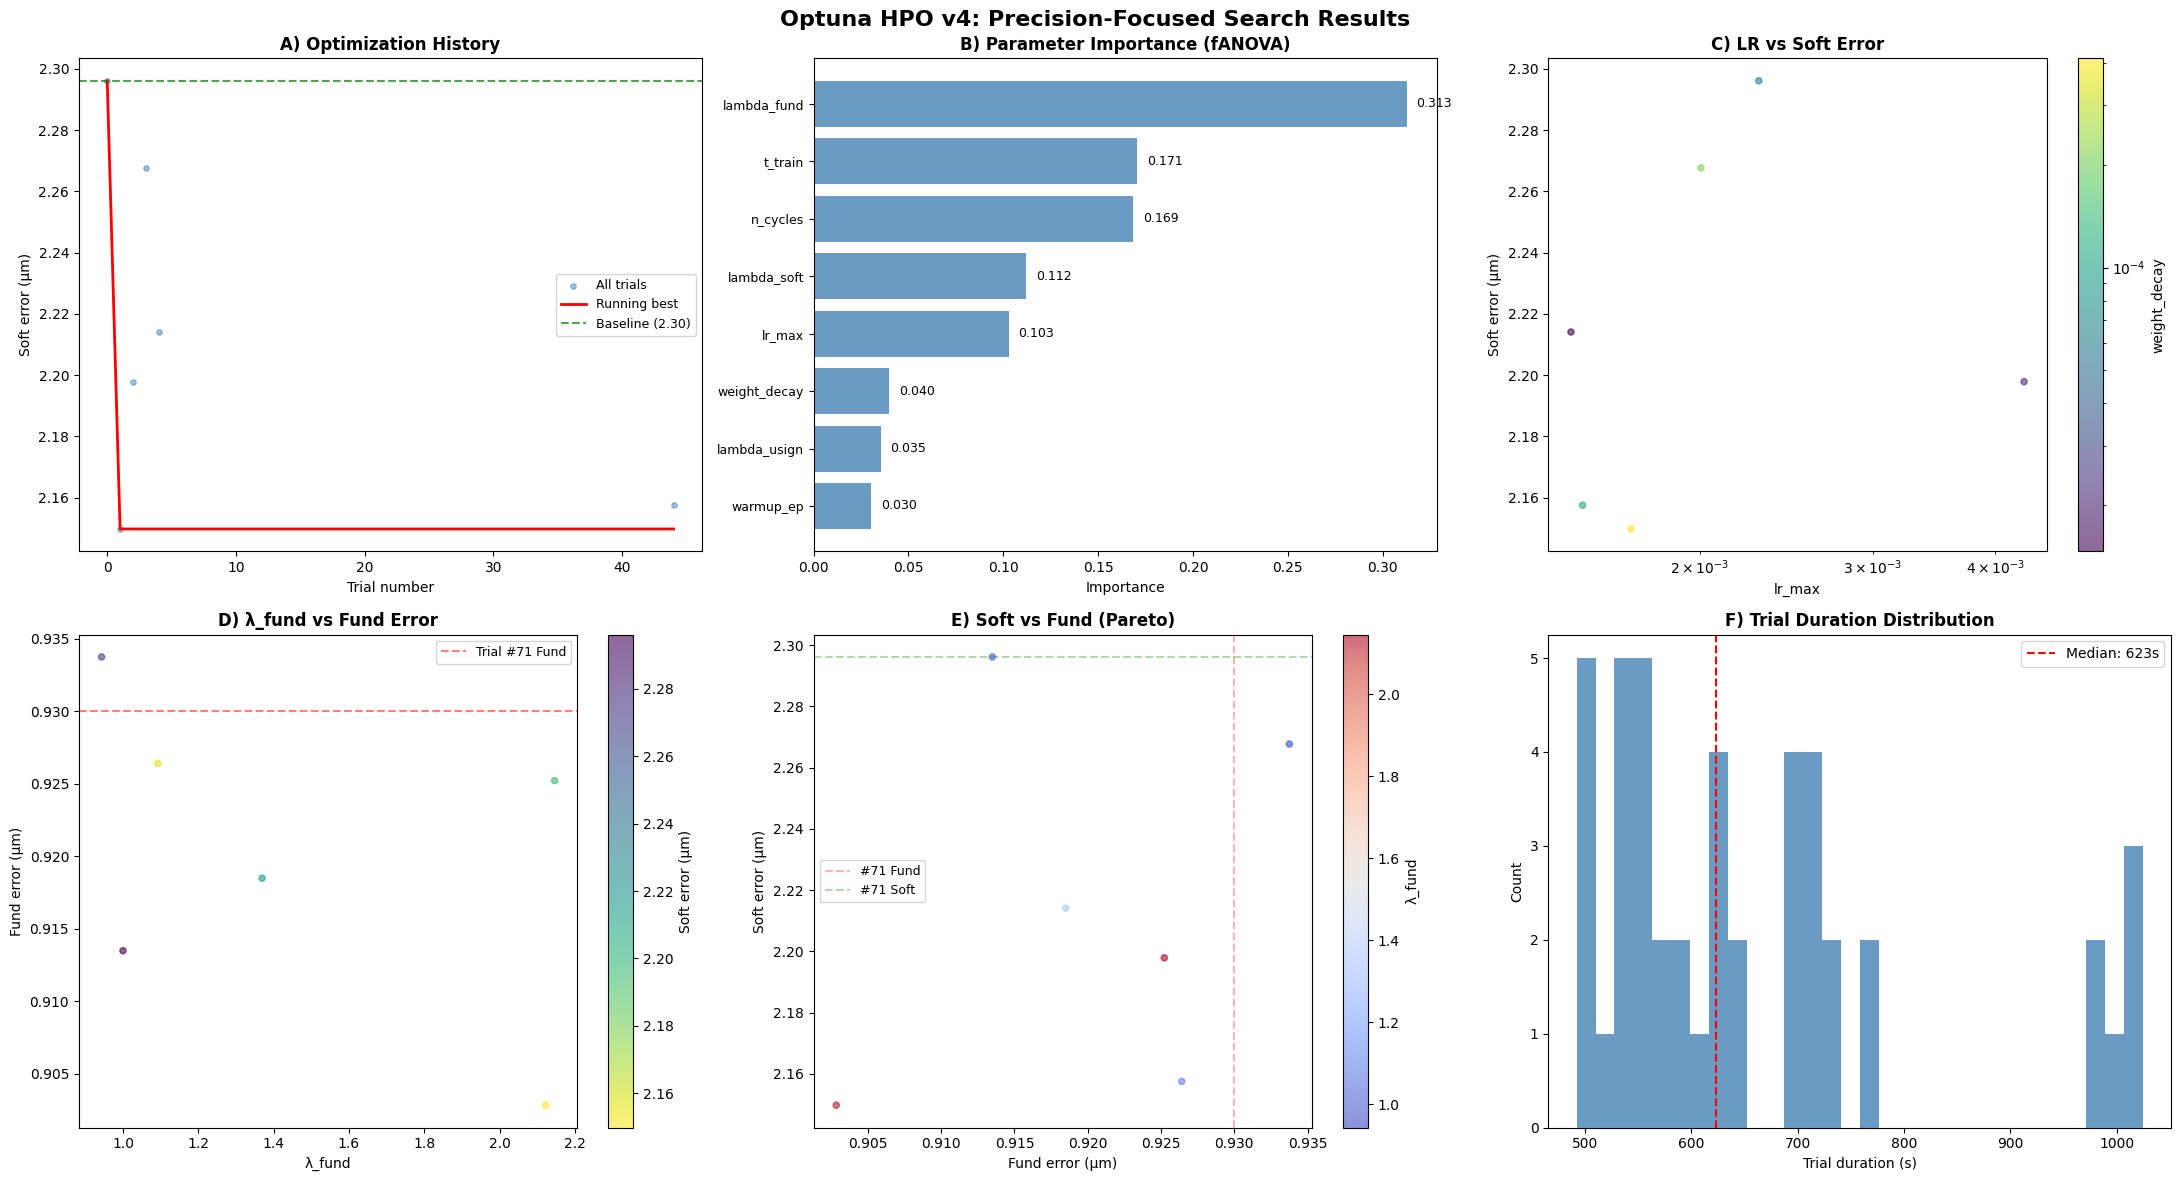

In [8]:
# ============================================================
# §8  Visualizations
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# A) Optimization history
ax = axes[0, 0]
trial_nums = [t.number for t in completed_sorted]
trial_vals = [t.value for t in completed_sorted]
all_vals = [(t.number, t.value) for t in completed]
all_vals.sort(key=lambda x: x[0])
ax.scatter([x[0] for x in all_vals], [x[1] for x in all_vals],
           s=15, alpha=0.5, c='steelblue', label='All trials')
# Running best
running_best = []
best_so_far = float('inf')
for num, val in all_vals:
    if val < best_so_far:
        best_so_far = val
    running_best.append((num, best_so_far))
ax.plot([x[0] for x in running_best], [x[1] for x in running_best],
        'r-', lw=2, label='Running best')
ax.axhline(bl_soft, color='green', ls='--', alpha=0.7, label=f'Baseline ({bl_soft:.2f})')
ax.set_xlabel('Trial number')
ax.set_ylabel('Soft error (µm)')
ax.set_title('A) Optimization History', fontweight='bold')
ax.legend(fontsize=9)

# B) Parameter importance (top-8)
ax = axes[0, 1]
try:
    importance = optuna.importance.get_param_importances(study)
    top_params = list(importance.keys())[:8]
    top_imp = [importance[p] for p in top_params]
    ax.barh(range(len(top_params)), top_imp[::-1], color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(top_params)))
    ax.set_yticklabels(top_params[::-1], fontsize=9)
    for i, v in enumerate(top_imp[::-1]):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
    ax.set_xlabel('Importance')
    ax.set_title('B) Parameter Importance (fANOVA)', fontweight='bold')
except Exception as e:
    ax.text(0.5, 0.5, f'Importance unavailable\n{e}',
            ha='center', va='center', transform=ax.transAxes)

# C) lr_max vs soft error
ax = axes[0, 2]
lr_vals = [t.params['lr_max'] for t in completed]
soft_vals = [t.value for t in completed]
sc = ax.scatter(lr_vals, soft_vals, c=[t.params['weight_decay'] for t in completed],
                s=20, alpha=0.6, cmap='viridis', norm=plt.matplotlib.colors.LogNorm())
plt.colorbar(sc, ax=ax, label='weight_decay')
ax.set_xscale('log')
ax.set_xlabel('lr_max')
ax.set_ylabel('Soft error (µm)')
ax.set_title('C) LR vs Soft Error', fontweight='bold')

# D) lambda_fund vs Fund error (KEY v4 plot)
ax = axes[1, 0]
lam_fund = [t.params['lambda_fund'] for t in completed]
fund_vals = [t.user_attrs.get('fund_err', float('nan')) for t in completed]
sc = ax.scatter(lam_fund, fund_vals, c=soft_vals, s=20, alpha=0.6, cmap='viridis_r')
plt.colorbar(sc, ax=ax, label='Soft error (µm)')
ax.axhline(0.930, color='red', ls='--', alpha=0.5, label='Trial #71 Fund')
ax.set_xlabel('λ_fund')
ax.set_ylabel('Fund error (µm)')
ax.set_title('D) λ_fund vs Fund Error', fontweight='bold')
ax.legend(fontsize=9)

# E) Soft vs Fund (Pareto front)
ax = axes[1, 1]
sc = ax.scatter(fund_vals, soft_vals, c=lam_fund, s=20, alpha=0.6, cmap='coolwarm')
plt.colorbar(sc, ax=ax, label='λ_fund')
ax.axvline(0.930, color='red', ls='--', alpha=0.3, label='#71 Fund')
ax.axhline(bl_soft, color='green', ls='--', alpha=0.3, label='#71 Soft')
ax.set_xlabel('Fund error (µm)')
ax.set_ylabel('Soft error (µm)')
ax.set_title('E) Soft vs Fund (Pareto)', fontweight='bold')
ax.legend(fontsize=9)

# F) Trial duration distribution
ax = axes[1, 2]
all_trials_time = []
for t in study.trials:
    if t.duration is not None:
        all_trials_time.append(t.duration.total_seconds())
if all_trials_time:
    ax.hist(all_trials_time, bins=30, color='steelblue', alpha=0.8, edgecolor='none')
    ax.axvline(np.median(all_trials_time), color='red', ls='--',
               label=f'Median: {np.median(all_trials_time):.0f}s')
    ax.set_xlabel('Trial duration (s)')
    ax.set_ylabel('Count')
    ax.set_title('F) Trial Duration Distribution', fontweight='bold')
    ax.legend()

plt.suptitle('Optuna HPO v4: Precision-Focused Search Results',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('optuna_hpo_v4_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ============================================================
# §9  Multi-Seed Validation (top-3 × 5 seeds × 800 ep)
# ============================================================

SEEDS = [42, 123, 2026, 7, 314]
TOP_K = 3

top_trials = completed_sorted[:TOP_K]
ms_time_est = TOP_K * len(SEEDS) * bl_time / 3600
print(f'Multi-seed validation: top-{TOP_K} × {len(SEEDS)} seeds × 800ep')
print(f'Estimated time: ~{ms_time_est:.1f}h')
print()

multiseed_results = []
for rank, t_obj in enumerate(top_trials, 1):
    t_params = dict(t_obj.params,
                    lambda_focal=1.181, focal_gamma=1.873,
                    focal_alpha_q0=0.894, focal_alpha_q1=0.867,
                    focal_alpha_q2=1.345, focal_alpha_q3=1.091,
                    mlp_hidden=128, dropout_mlp=0.227, dropout_fusion=0.038,
                    batch_size=384, aug_noise_std=0.023, aug_shift_max=3,
                    aug_scale_range=0.052, epochs=800)
    softs_this, funds_this = [], []
    print(f'--- Rank {rank}: Trial #{t_obj.number} '
          f'(Soft={t_obj.value:.3f}, Fund={t_obj.user_attrs.get("fund_err",0):.3f}, '
          f'λ_fund={t_obj.params["lambda_fund"]:.2f}) ---')
    for seed in SEEDS:
        t0 = time.time()
        soft, fund, acc, ep, _ = run_phase1_trial(t_params, seed=seed)
        dt = time.time() - t0
        softs_this.append(soft); funds_this.append(fund)
        multiseed_results.append({
            'trial': t_obj.number, 'rank': rank, 'seed': seed,
            'soft': soft, 'fund': fund, 'acc': acc, 'time': dt})
        print(f'  seed={seed:4d}  Soft={soft:.3f}  Fund={fund:.3f}  Acc={acc:.1%}  ({dt:.0f}s)')
    print(f'  → Soft: {np.mean(softs_this):.3f} ± {np.std(softs_this):.3f}  |  '
          f'Fund: {np.mean(funds_this):.3f} ± {np.std(funds_this):.3f}\n')

# Summary
print('='*70)
print(f'{"Rank":>4} {"Trial":>6} {"λ_fund":>7} {"Soft_mean":>10} {"Soft_std":>9} '
      f'{"Fund_mean":>10} {"Fund_std":>9}')
print('-'*70)
for rank in range(1, TOP_K + 1):
    rows = [r for r in multiseed_results if r['rank'] == rank]
    s = [r['soft'] for r in rows]
    f = [r['fund'] for r in rows]
    trial_n = rows[0]['trial']
    t_obj = [t for t in completed if t.number == trial_n][0]
    lf = t_obj.params['lambda_fund']
    print(f'{rank:4d} {trial_n:6d} {lf:7.2f} {np.mean(s):10.3f} {np.std(s):9.3f} '
          f'{np.mean(f):10.3f} {np.std(f):9.3f}')

# Find the most robust winner (by Soft mean)
all_means = []
for rank in range(1, TOP_K + 1):
    rows = [r for r in multiseed_results if r['rank'] == rank]
    s = [r['soft'] for r in rows]
    f = [r['fund'] for r in rows]
    all_means.append((rank, rows[0]['trial'], np.mean(s), np.std(s), np.mean(f)))
all_means.sort(key=lambda x: x[2])
best_robust = all_means[0]
print(f'\nBest robust: Trial #{best_robust[1]} → '
      f'Soft = {best_robust[2]:.3f} ± {best_robust[3]:.3f} µm  |  '
      f'Fund = {best_robust[4]:.3f} µm')

# Store for export
qsofts = [r['soft'] for r in multiseed_results if r['trial'] == best_robust[1]]
qfunds = [r['fund'] for r in multiseed_results if r['trial'] == best_robust[1]]

Multi-seed validation: top-3 × 5 seeds × 800ep
Estimated time: ~4.1h

--- Rank 1: Trial #1 (Soft=2.150, Fund=0.903, λ_fund=2.12) ---


  seed=  42  Soft=2.150  Fund=0.903  Acc=88.4%  (1022s)


  seed= 123  Soft=2.316  Fund=0.980  Acc=87.4%  (1010s)


  seed=2026  Soft=2.127  Fund=0.930  Acc=88.3%  (1033s)


  seed=   7  Soft=2.280  Fund=0.939  Acc=88.4%  (1044s)


...

  seed=2026  Soft=2.305  Fund=0.927  Acc=87.8%  (1029s)


  seed=   7  Soft=2.267  Fund=0.920  Acc=87.7%  (1025s)


  seed= 314  Soft=2.207  Fund=0.944  Acc=88.0%  (1021s)
  → Soft: 2.255 ± 0.065  |  Fund: 0.931 ± 0.008

--- Rank 3: Trial #2 (Soft=2.198, Fund=0.925, λ_fund=2.15) ---


  seed=  42  Soft=2.198  Fund=0.925  Acc=88.6%  (1040s)


  seed= 123  Soft=2.288  Fund=0.979  Acc=88.5%  (1038s)


In [ ]:
# ============================================================
# §10  Export: Copy-Paste Block for NB_Model_Training
# ============================================================

# Use the most robust trial (best mean across 5 seeds)
best_trial_num = best_robust[1]
best_trial_obj = [t for t in completed if t.number == best_trial_num][0]

# Merge searched params with frozen + fixed
bp = dict(best_trial_obj.params,
          lambda_focal=1.181, focal_gamma=1.873,
          focal_alpha_q0=0.894, focal_alpha_q1=0.867,
          focal_alpha_q2=1.345, focal_alpha_q3=1.091,
          mlp_hidden=128, dropout_mlp=0.227, dropout_fusion=0.038,
          batch_size=384, aug_noise_std=0.023, aug_shift_max=3,
          aug_scale_range=0.052)

print('# ============================================================')
print('# Optuna v4 hyperparameters (copy to NB_Model_Training)')
print('# ============================================================')
print(f'# Source: NB_Optuna_HPO v4, Trial #{best_trial_num}')
print(f'# Soft (800ep, single): {best_trial_obj.value:.3f} µm')
print(f'# Soft (5-seed mean):   {np.mean(qsofts):.3f} ± {np.std(qsofts):.3f} µm')
print(f'# Fund (5-seed mean):   {np.mean(qfunds):.3f} ± {np.std(qfunds):.3f} µm')
print()
print(f'BATCH       = {bp["batch_size"]}')
print(f'LR_MAX      = {bp["lr_max"]:.6f}')
print(f'W_DECAY     = {bp["weight_decay"]:.6f}')
print(f'WARMUP_EP   = {bp["warmup_ep"]}')
print(f'N_CYCLES    = {bp["n_cycles"]}')
print(f'ETA_MIN     = {bp["eta_min"]:.2e}')
print()
print(f'LAMBDA_FUND  = {bp["lambda_fund"]:.4f}    # KEY v4 change (was fixed at 1.0)')
print(f'LAMBDA_FOCAL = {bp["lambda_focal"]:.4f}    # frozen at trial #71')
print(f'LAMBDA_SOFT  = {bp["lambda_soft"]:.4f}')
print(f'LAMBDA_USIGN = {bp["lambda_usign"]:.4f}')
print()
print(f'T_TRAIN = {bp["t_train"]:.4f}')
print(f'T_INFER = 0.1')
print()
print(f'focal_loss = FocalLoss(gamma={bp["focal_gamma"]:.4f}, '
      f'alpha=[{bp["focal_alpha_q0"]:.4f}, {bp["focal_alpha_q1"]:.4f}, '
      f'{bp["focal_alpha_q2"]:.4f}, {bp["focal_alpha_q3"]:.4f}]).to(device)')
print()
print('# Architecture (unchanged):')
print(f'#   mlp_hidden = 128, dropout_mlp = 0.227, dropout_fusion = 0.038')
print('# Augmentation (unchanged):')
print(f'#   noise_std = 0.023, shift_max = 3, scale_range = 0.052')
print()

# Show changes vs trial #71
print('# Changes vs trial #71 (v2 anchor):')
ref = BEST_V2_PARAMS
for k in ['lr_max', 'weight_decay', 'warmup_ep', 'n_cycles', 'eta_min',
          'lambda_fund', 'lambda_focal', 'lambda_soft', 'lambda_usign', 't_train',
          'focal_gamma', 'focal_alpha_q0', 'focal_alpha_q1',
          'focal_alpha_q2', 'focal_alpha_q3']:
    new_v = bp[k]
    old_v = ref[k]
    if isinstance(new_v, float) and isinstance(old_v, (int, float)) and old_v != 0:
        ratio = new_v / old_v
        if abs(ratio - 1) > 0.05:
            print(f'#   {k}: {old_v} → {new_v:.4f} (×{ratio:.2f})')
    elif new_v != old_v:
        print(f'#   {k}: {old_v} → {new_v}')

---

## Summary

**Optuna HPO v4** — Precision-focused search with symmetry HPs locked at trial #71.

**Motivation:** v2 trial #71 improved Soft (2.24→2.13 µm) mainly via Acc (87.5→88.4%),
but Fund *worsened* (0.87→0.93 µm). Pre-Optuna configs showed Fund=0.87 is achievable.
By locking the already-optimized symmetry HPs and unlocking `lambda_fund`, we let TPE
focus on improving fundamental-domain precision without losing the classification gains.

| Stage | Method | Purpose |
|-------|--------|---------|
| §1–§3 | Setup | Load data, define parameterized model/loss/training (λ_fund searchable) |
| §4 | Search space | 9 HP: optimizer, schedule, **λ_fund (NEW)**, λ_soft, λ_usign, t_train |
| §5 | Baseline | Run trial #71 @ 800ep (λ_fund=1.0) to calibrate |
| §6 | Main search | TPE + **PercentilePruner(30%)**, 500ep warmup, **8h** budget |
| §7–§8 | Analysis | Top-10 ranking, importance, Soft-vs-Fund Pareto, λ_fund impact |
| §9 | Multi-seed | **Top-3 × 5 seeds × 800ep** → robust winner (tracks Fund + Soft) |
| §10 | Export | Copy-paste block for NB_Model_Training (includes λ_fund) |

**Frozen at trial #71 (6 HP):** `focal_gamma=1.873`, `focal_alpha=[0.894, 0.867, 1.345, 1.091]`, `lambda_focal=1.181`
**Time budget:** ~8h search + ~3h multi-seed = ~11h total (≤11.5h Kaggle limit)

---
*Author: Ibón García-Gutiérrez · Research Project · 2026*